In [1]:
#importing neccessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

In [2]:
#reading dataset
df=pd.read_csv(r"C:\data sets\spotify_data clean (1).csv")
print(df.head())

                 track_id                                       track_name  \
0  3EJS5LyekDim1Tf5rBFmZl                    Trippy Mane (ft. Project Pat)   
1  1oQW6G2ZiwMuHqlPpP27DB                                             OMG!   
2  7mdkjzoIYlf1rx9EtBpGmU                                      Hard 2 Find   
3  67rW0Zl7oB3qEpD5YWWE5w  Still Get Like That (ft. Project Pat & Starrah)   
4  15xptTfRBrjsppW0INUZjf                            ride me like a harley   

   track_number  track_popularity  explicit artist_name  artist_popularity  \
0             4                 0      True       Diplo                 77   
1             1                 0      True    Yelawolf                 64   
2             1                 4      True   Riff Raff                 48   
3             8                30      True       Diplo                 77   
4             2                 0      True     Rumelis                 48   

   artist_followers                      artist_genres  \
0   

In [3]:
#checking columns
df.columns

Index(['track_id', 'track_name', 'track_number', 'track_popularity',
       'explicit', 'artist_name', 'artist_popularity', 'artist_followers',
       'artist_genres', 'album_id', 'album_name', 'album_release_date',
       'album_total_tracks', 'album_type', 'track_duration_min'],
      dtype='object')

In [4]:
#checking dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8582 entries, 0 to 8581
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   track_id            8582 non-null   object 
 1   track_name          8582 non-null   object 
 2   track_number        8582 non-null   int64  
 3   track_popularity    8582 non-null   int64  
 4   explicit            8582 non-null   bool   
 5   artist_name         8579 non-null   object 
 6   artist_popularity   8582 non-null   int64  
 7   artist_followers    8582 non-null   int64  
 8   artist_genres       5221 non-null   object 
 9   album_id            8582 non-null   object 
 10  album_name          8582 non-null   object 
 11  album_release_date  8582 non-null   object 
 12  album_total_tracks  8582 non-null   int64  
 13  album_type          8582 non-null   object 
 14  track_duration_min  8582 non-null   float64
dtypes: bool(1), float64(1), int64(5), object(8)
memory usag

DATA PREPROCESSING 


In [5]:
#checking null values
print(df.isnull().sum())

track_id                 0
track_name               0
track_number             0
track_popularity         0
explicit                 0
artist_name              3
artist_popularity        0
artist_followers         0
artist_genres         3361
album_id                 0
album_name               0
album_release_date       0
album_total_tracks       0
album_type               0
track_duration_min       0
dtype: int64


In [6]:
#handling artist_genres missing values
df['artist_genres']=df['artist_genres'].fillna('Unknown')
print(df['artist_genres'].isnull().sum())

0


In [7]:
#checking duplicate values
print(df[df.duplicated()])

Empty DataFrame
Columns: [track_id, track_name, track_number, track_popularity, explicit, artist_name, artist_popularity, artist_followers, artist_genres, album_id, album_name, album_release_date, album_total_tracks, album_type, track_duration_min]
Index: []


In [8]:
#removing unwanted columns
df=df.drop(columns=df.columns[[0,9]],axis=1)
print(df.head())

                                        track_name  track_number  \
0                    Trippy Mane (ft. Project Pat)             4   
1                                             OMG!             1   
2                                      Hard 2 Find             1   
3  Still Get Like That (ft. Project Pat & Starrah)             8   
4                            ride me like a harley             2   

   track_popularity  explicit artist_name  artist_popularity  \
0                 0      True       Diplo                 77   
1                 0      True    Yelawolf                 64   
2                 4      True   Riff Raff                 48   
3                30      True       Diplo                 77   
4                 0      True     Rumelis                 48   

   artist_followers                      artist_genres  \
0           2812821                         moombahton   
1           2363438  country hip hop, southern hip hop   
2            193302             

In [9]:
#coverting track duration from minutes to seconds
def mintosec(m):
    m=m*60
    return m
df['track_duration_min']=df['track_duration_min'].apply(mintosec).astype(int)

print(df['track_duration_min'])

0        93
1       184
2       153
3       101
4       143
       ... 
8577    235
8578    259
8579    136
8580    164
8581    121
Name: track_duration_min, Length: 8582, dtype: int64


In [10]:
#renaming of column track_duration_min
df.rename(columns={'track_duration_min':'track_duration_sec'},inplace=True)

PROBLEM STATEMENT 1:Which artist dominate spotify?

In [11]:
data=df.groupby('artist_name').agg({'artist_followers':'max','artist_popularity':'max','track_popularity':'mean'}).reset_index()
print(data)

           artist_name  artist_followers  artist_popularity  track_popularity
0          $uicideboy$           8957416                 83              31.5
1           'Ery Noice             11720                 25              15.0
2             (((())))             49519                 51              23.0
3               *NSYNC           3088613                 69              79.0
4                    -               714                 28              45.0
...                ...               ...                ...               ...
2542  攬佬SKAI ISYOURGOD            298654                 64              62.0
2543         時瀬高等学校箏曲部              2625                 22              36.0
2544              桑原まこ               346                 12               0.0
2545             梶浦 由記            132111                 53              37.0
2546              藤澤慶昌             13575                 40              21.0

[2547 rows x 4 columns]


In [12]:
data.rename(columns={'track_popularity':'avg_track_popularity'})

,artist_name,artist_followers,artist_popularity,avg_track_popularity
0,$uicideboy$,8957416,83,31.5
1,'Ery Noice,11720,25,15.0
2,(((()))),49519,51,23.0
3,*NSYNC,3088613,69,79.0
4,-,714,28,45.0
...,...,...,...,...
2542,攬佬SKAI ISYOURGOD,298654,64,62.0
2543,時瀬高等学校箏曲部,2625,22,36.0
2544,桑原まこ,346,12,0.0
2545,梶浦 由記,132111,53,37.0


In [13]:
#top 20 artist by followers
data.sort_values(by=['artist_followers','artist_popularity'],inplace=True,ascending=False)
print(data.head(20))

          artist_name  artist_followers  artist_popularity  track_popularity
2121     Taylor Swift         145542136                100         60.049383
624        Ed Sheeran         122802777                 88         60.283019
260     Billie Eilish         118797451                 90         73.885246
2222       The Weeknd         113039308                 94         60.787234
145     Ariana Grande         107418606                 90         63.914894
656            Eminem         104584370                 88         56.253731
597             Drake         103126025                 95         65.892857
209         Bad Bunny         102610644                 95         73.339286
1100    Justin Bieber          85050158                 91         66.272727
199               BTS          81197976                 85         57.433333
329        Bruno Mars          75513910                 90         66.407407
1826          Rihanna          69050055                 90         65.576923

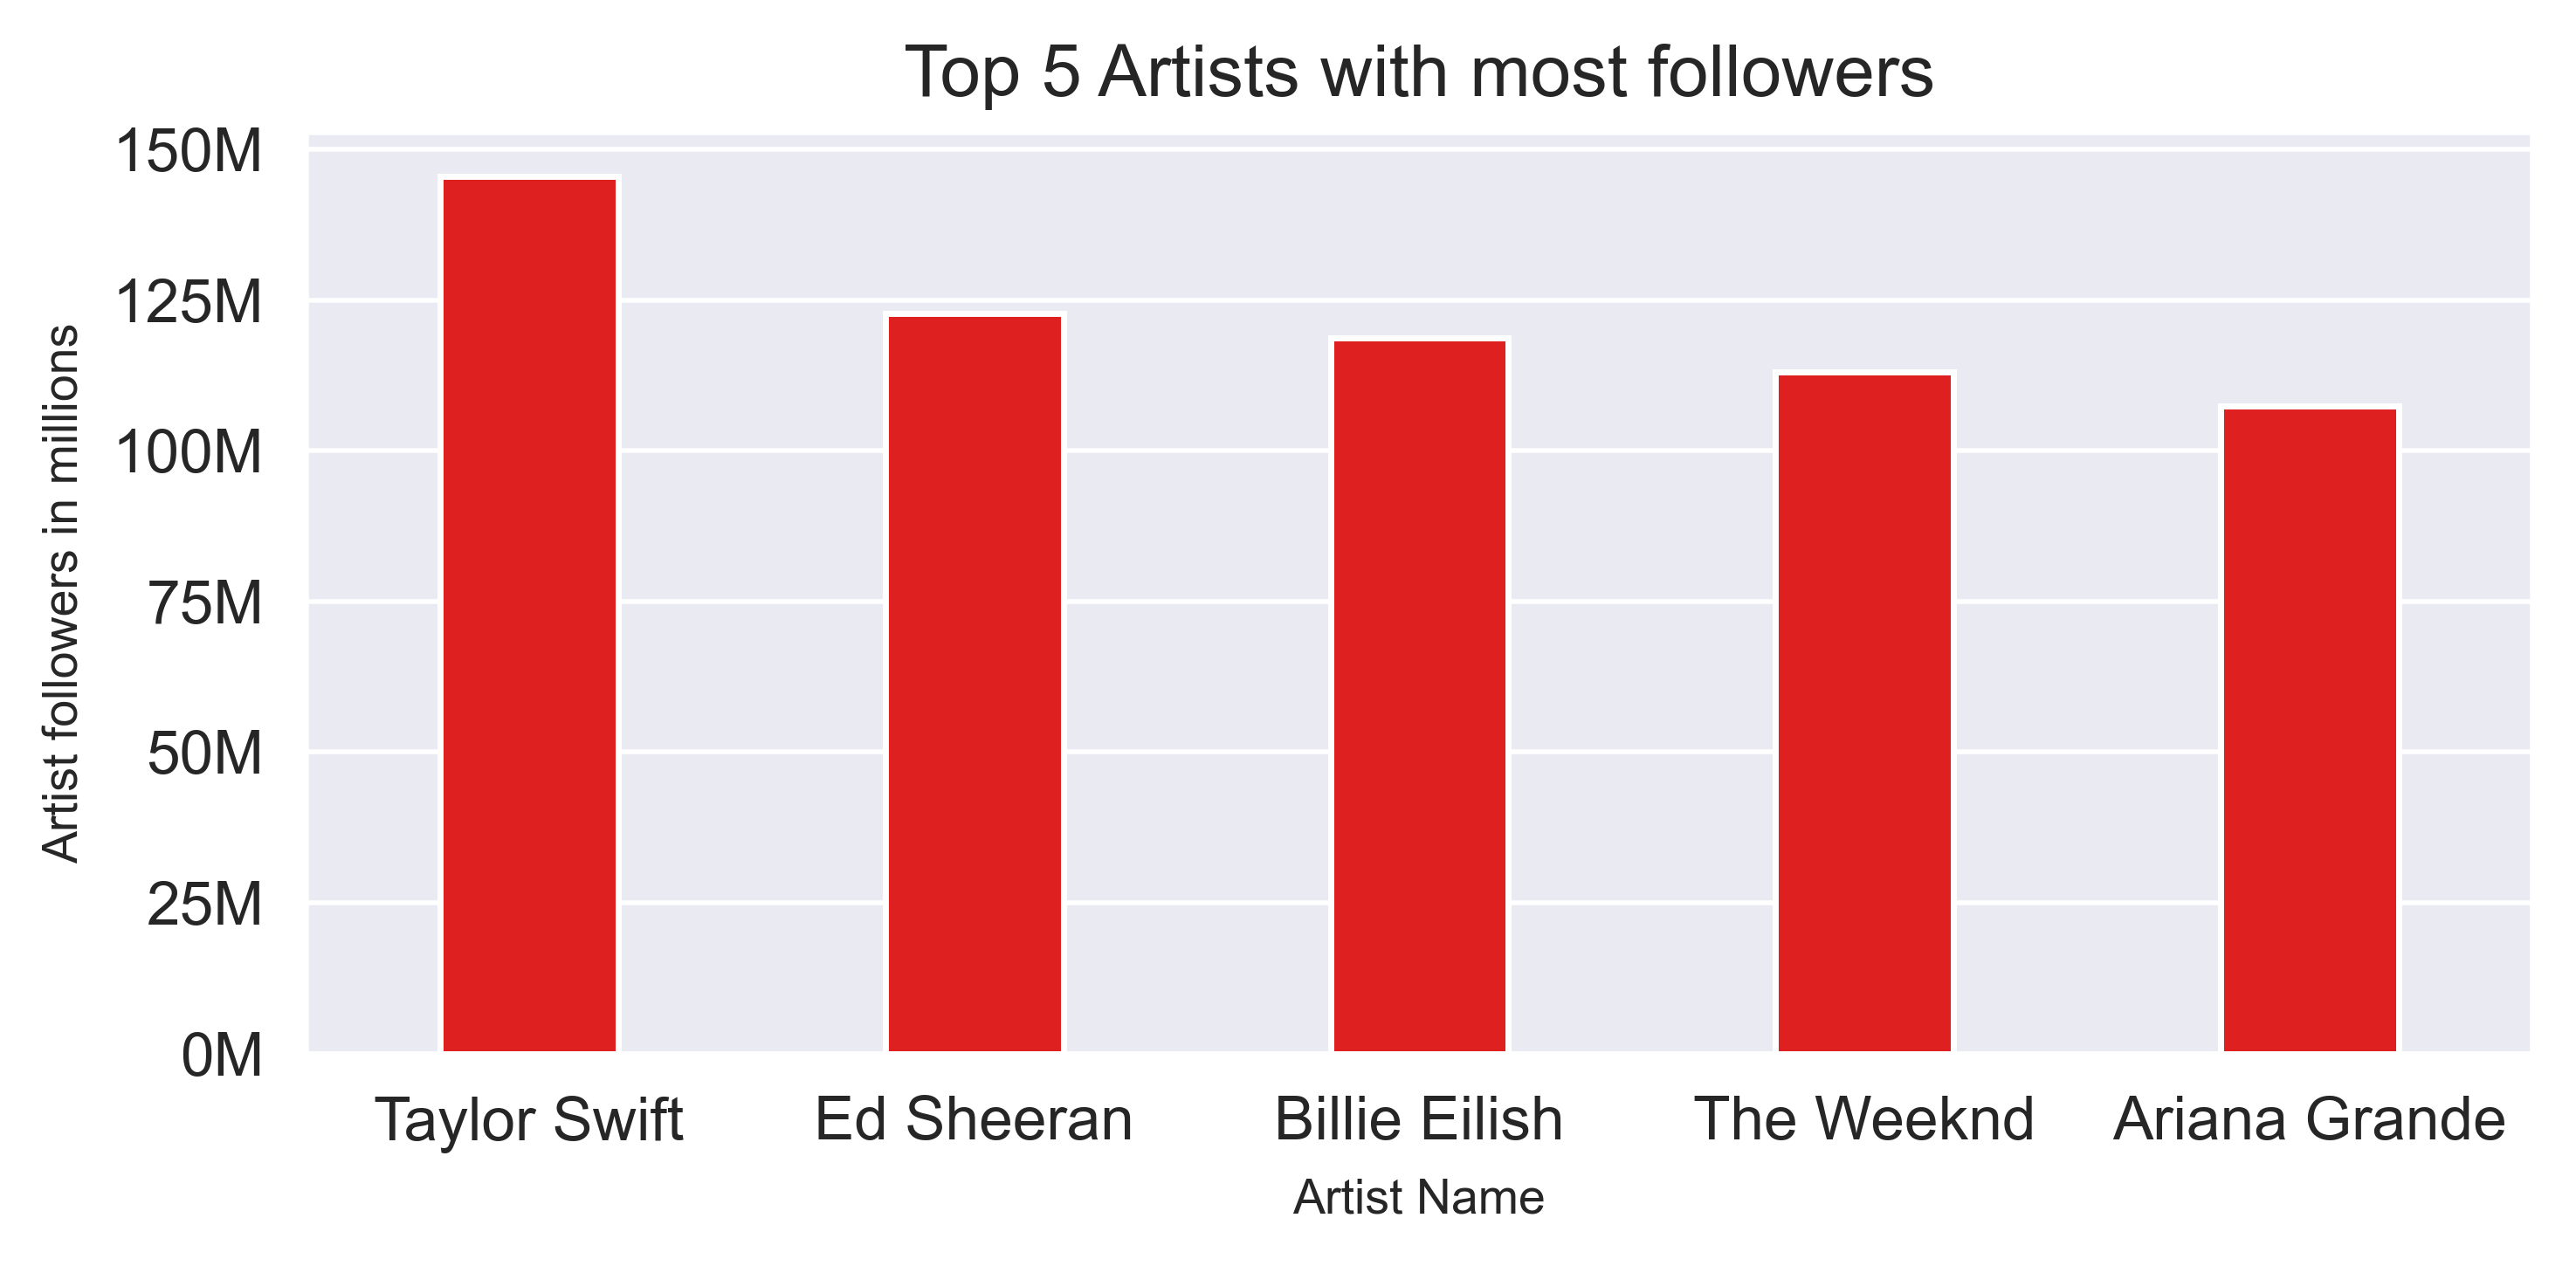

In [21]:
sns.set_style('darkgrid')
plt.figure(dpi=500,figsize=(6,3))
sns.barplot(data=data.head(5),x='artist_name',y='artist_followers',width=0.4,color='red')
plt.ylabel('Artist followers in millions',size=8)
plt.xlabel('Artist Name',size=8)
plt.title('Top 5 Artists with most followers',size=12)
ax=plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x,pos:f'{x/1000000:.0f}M'))
plt.tight_layout()
plt.savefig('spotifyimage2.png')
plt.show()


PROBLEM STATEMENT 2:Does song duration affects popularity?

In [15]:
df.columns

Index(['track_name', 'track_number', 'track_popularity', 'explicit',
       'artist_name', 'artist_popularity', 'artist_followers', 'artist_genres',
       'album_name', 'album_release_date', 'album_total_tracks', 'album_type',
       'track_duration_sec'],
      dtype='object')

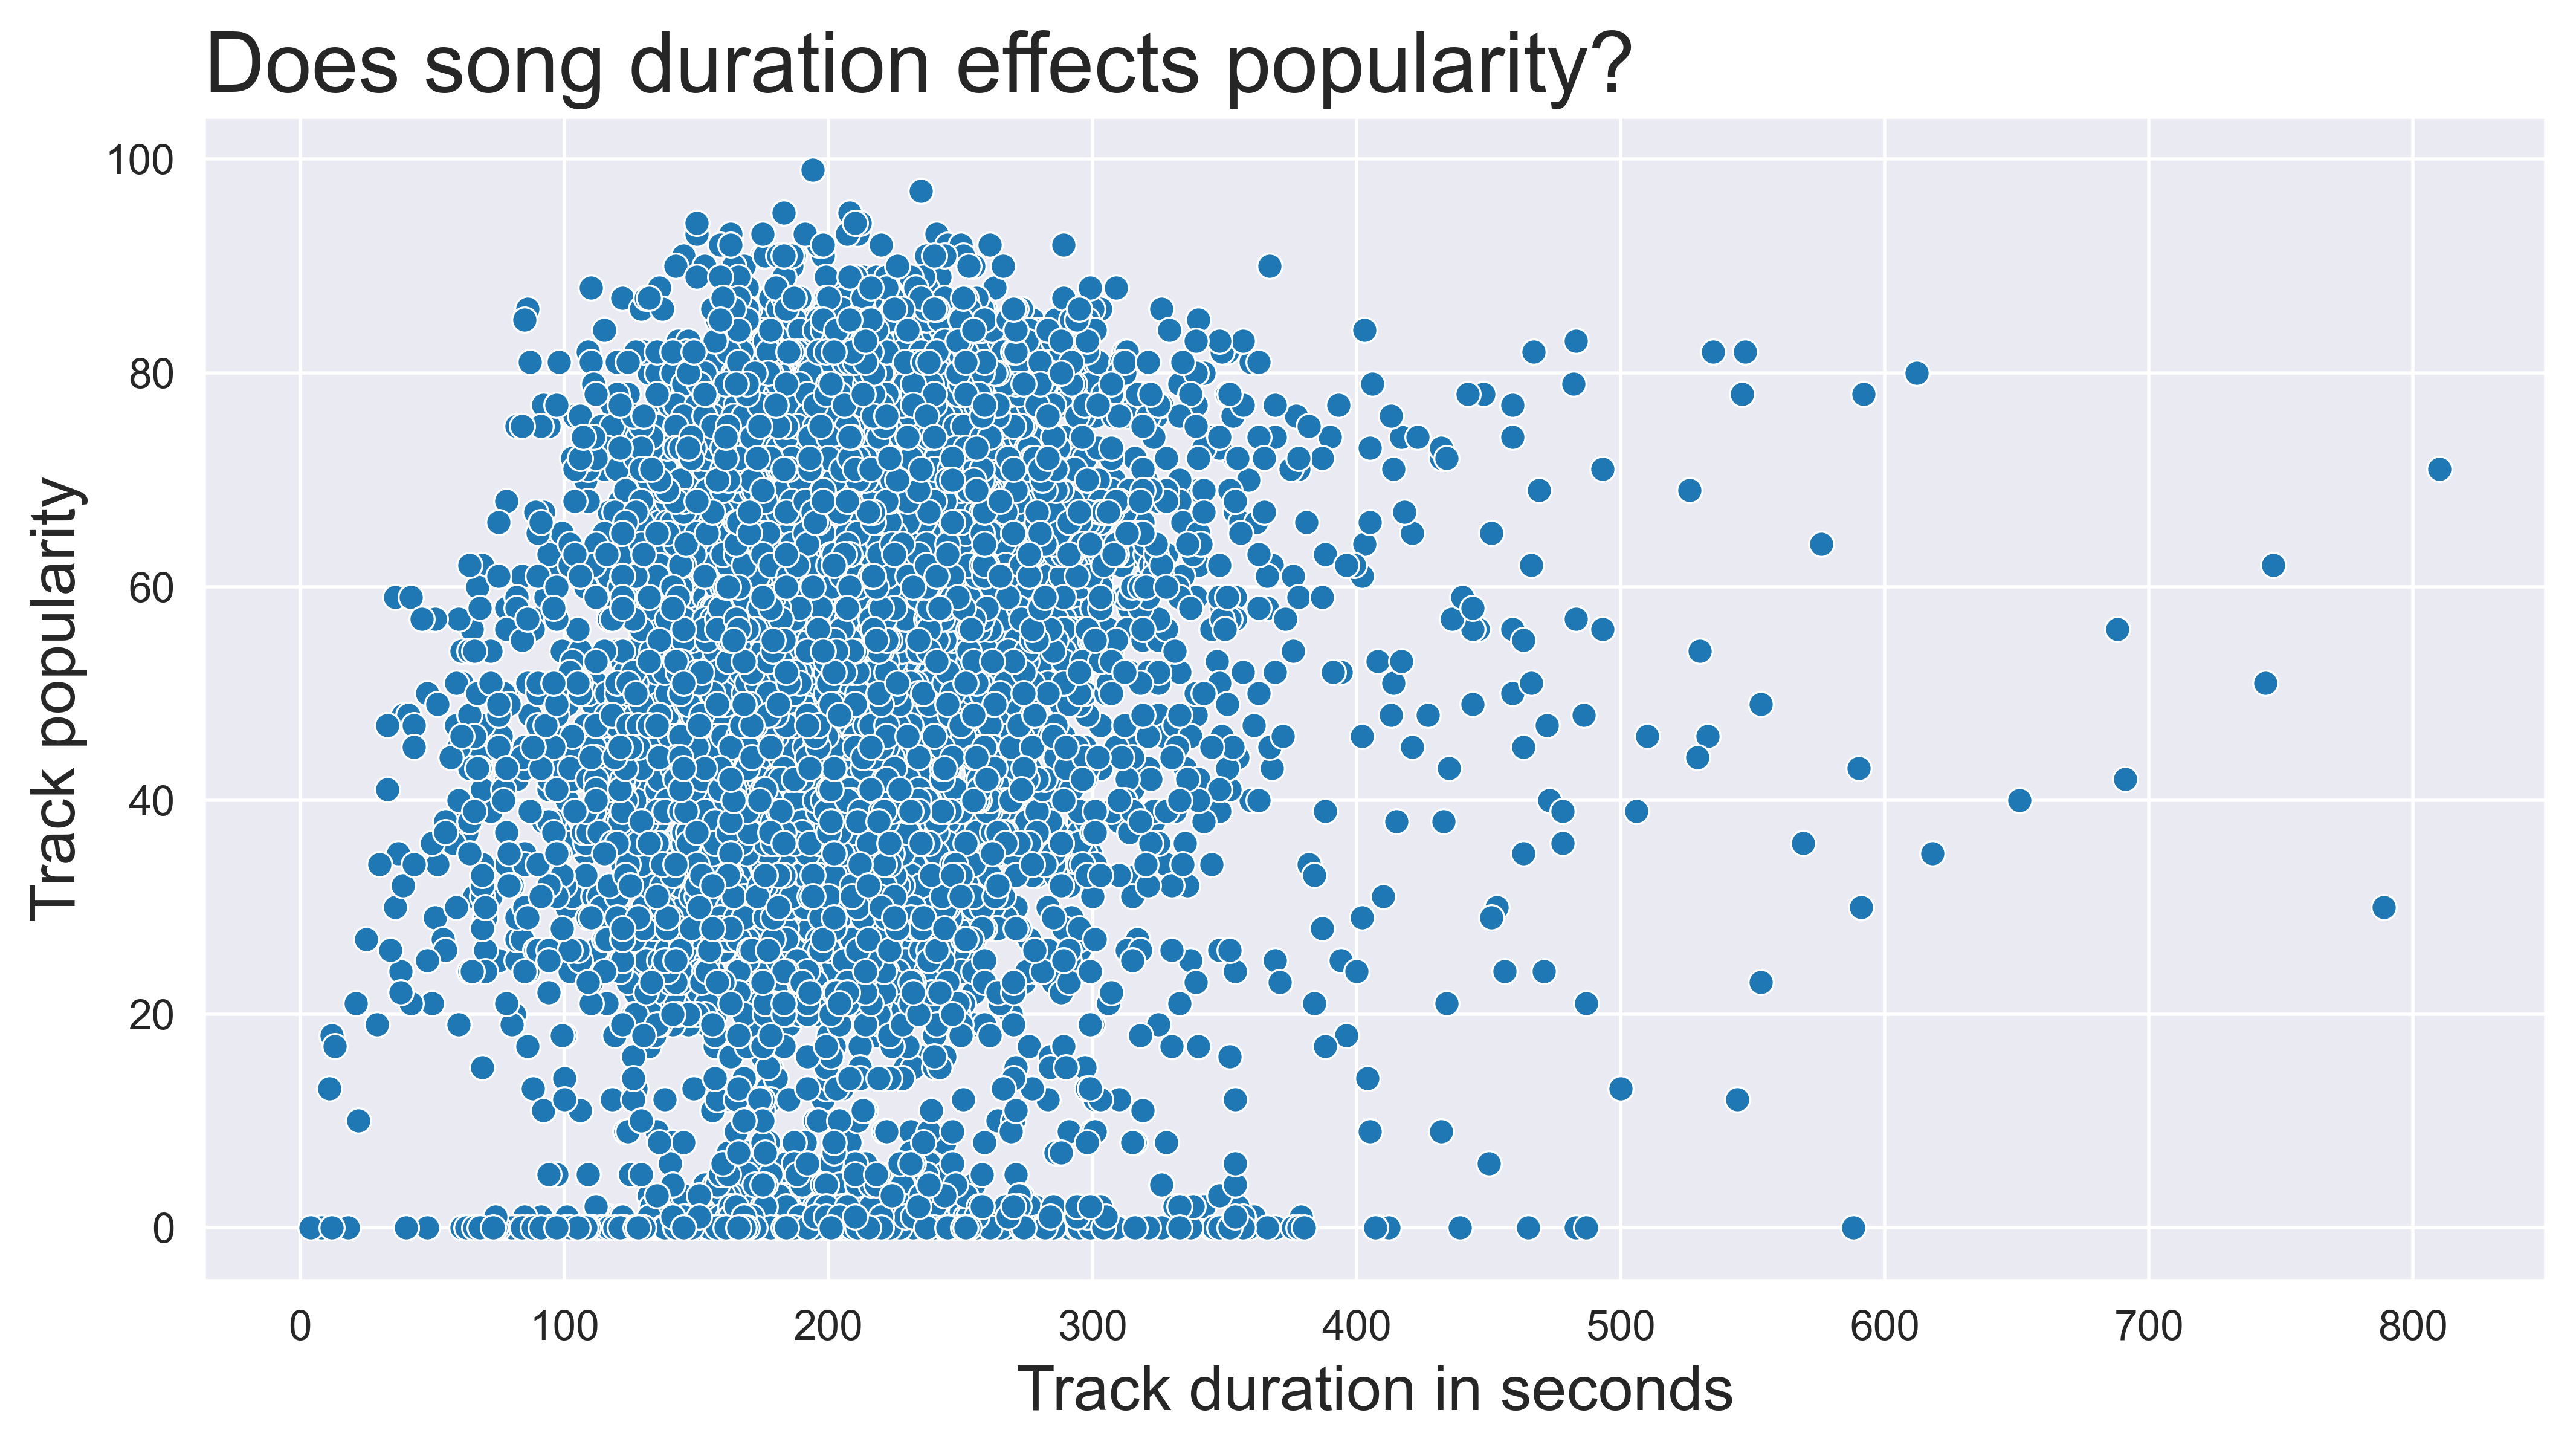

In [16]:
plt.figure(figsize=(10,5),dpi=500)
sns.scatterplot(data=df,x='track_duration_sec',y='track_popularity')
plt.xlabel('Track duration in seconds',size=15)
plt.ylabel('Track popularity',size=15)
plt.title('Does song duration effects popularity?',size=20,loc='left')
plt.savefig('spotifyimage1.png')
plt.show()

INSIGHTS: Both short and long songs can succeed or fail.
 The clustering around 180–240 seconds (≈3–4 minutes) reflects industry norms—radio-friendly lengths that maximize listener engagement without overstaying.
 While most hits fit the standard duration, some longer tracks can still achieve popularity, but they are rare.

PROBLEM STATEMENT2:What factors influence a song's popularity?

In [22]:
df.columns

Index(['track_name', 'track_number', 'track_popularity', 'explicit',
       'artist_name', 'artist_popularity', 'artist_followers', 'artist_genres',
       'album_name', 'album_release_date', 'album_total_tracks', 'album_type',
       'track_duration_sec'],
      dtype='object')

In [23]:
#taking required columns
data2=df[['track_popularity','artist_popularity','artist_followers','track_duration_sec','album_total_tracks','explicit']]
print(data2.head())

   track_popularity  artist_popularity  artist_followers  track_duration_sec  \
0                 0                 77           2812821                  93   
1                 0                 64           2363438                 184   
2                 4                 48            193302                 153   
3                30                 77           2813710                 101   
4                 0                 48              8682                 143   

   album_total_tracks  explicit  
0                   9      True  
1                   1      True  
2                   1      True  
3                   9      True  
4                   2      True  


In [24]:
data2['explicit']=data2['explicit'].astype(int)

C:\Users\chara\AppData\Local\Temp\ipykernel_20348\2434714191.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data2['explicit']=data2['explicit'].astype(int)


In [25]:
data2.head()

,track_popularity,artist_popularity,artist_followers,track_duration_sec,album_total_tracks,explicit
0,0,77,2812821,93,9,1
1,0,64,2363438,184,1,1
2,4,48,193302,153,1,1
3,30,77,2813710,101,9,1
4,0,48,8682,143,2,1


In [27]:
corr=data2.corr()
corr

,track_popularity,artist_popularity,artist_followers,track_duration_sec,album_total_tracks,explicit
track_popularity,1.000000,0.466903,0.232019,0.105550,-0.053461,0.132526
artist_popularity,0.466903,1.000000,0.635579,0.207778,0.199335,0.175295
artist_followers,0.232019,0.635579,1.000000,0.172066,0.183718,0.104194
track_duration_sec,0.105550,0.207778,0.172066,1.000000,0.064741,0.007649
album_total_tracks,-0.053461,0.199335,0.183718,0.064741,1.000000,-0.060824
explicit,0.132526,0.175295,0.104194,0.007649,-0.060824,1.000000


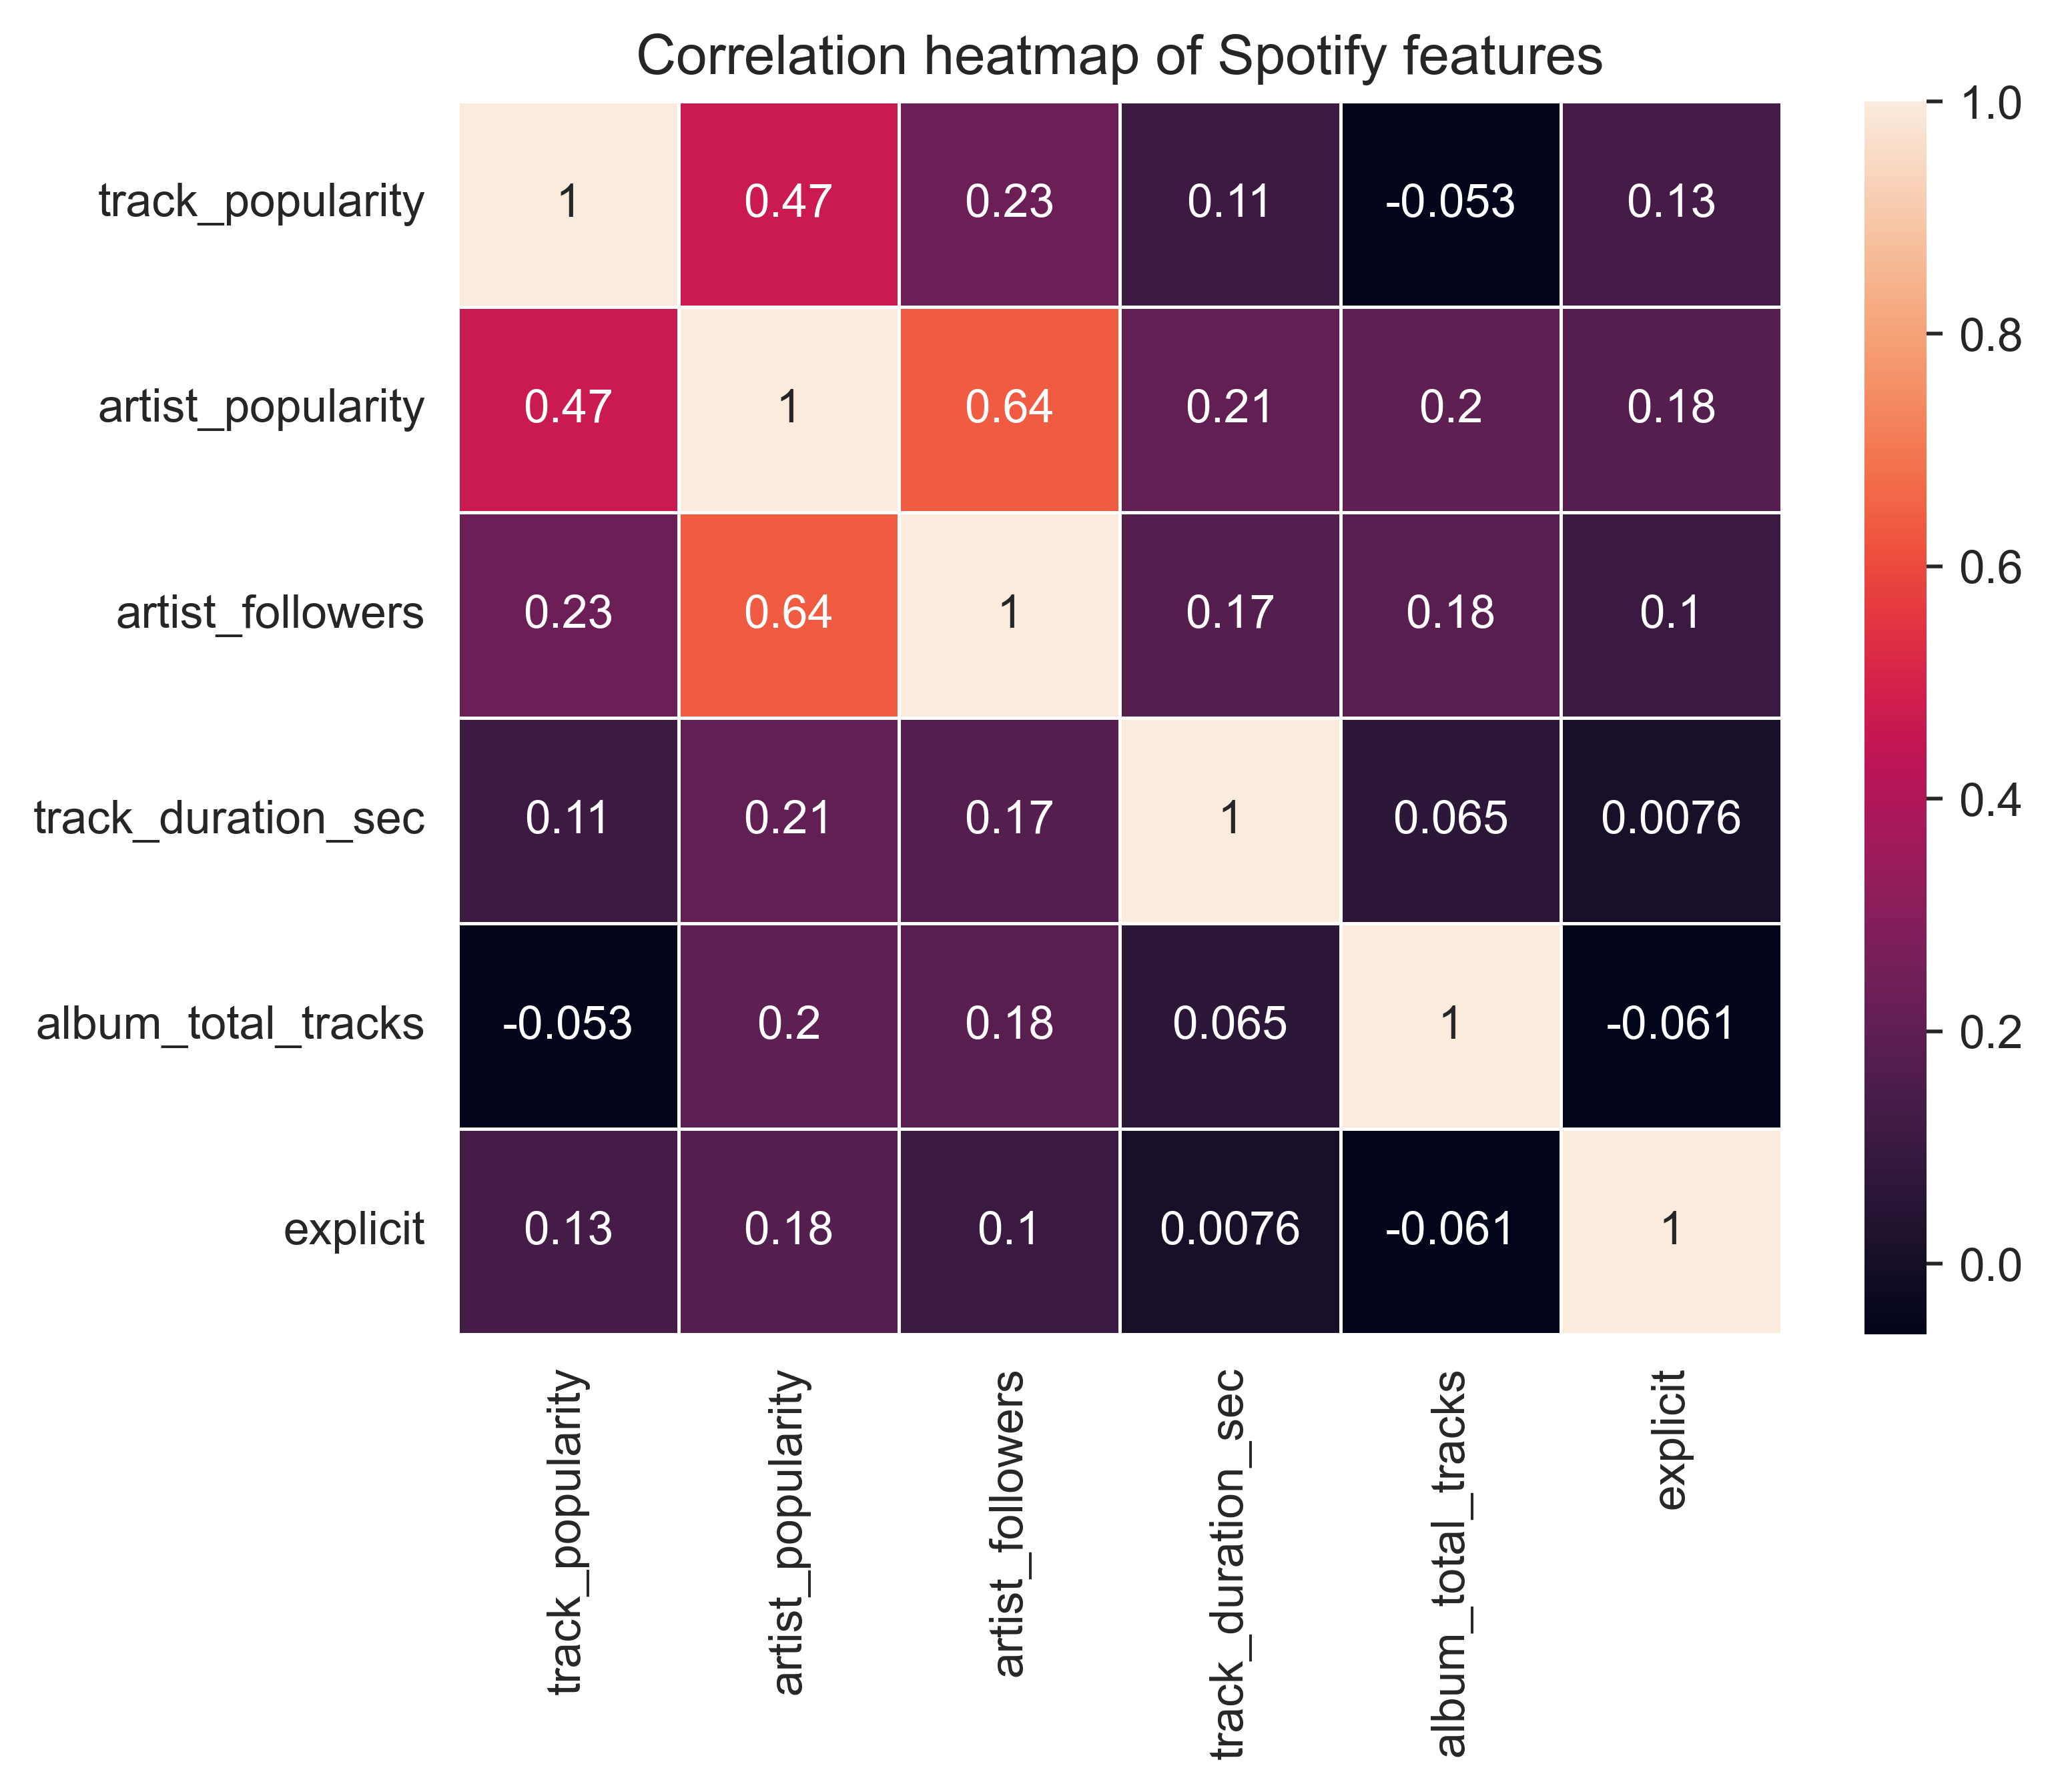

In [40]:
plt.figure(dpi=500)
sns.heatmap(data=corr,annot=True,linewidths=0.5)
plt.title('Correlation heatmap of Spotify features',size=12)
plt.savefig('spotifyimage3.png')
plt.show()

INSIGHTS:
Followers drive popularity: Artist popularity is most strongly linked to follower count (0.64), showing fan engagement is the biggest factor.

Track success and artist success overlap but differ: Track popularity moderately correlates with artist popularity (0.47), meaning hit songs help—but don’t fully define—an artist’s fame.

Other features matter little: Duration, catalog size, and explicit content show weak or negligible correlations, so they don’t significantly influence popularit